# Ejercicio 3: Inspección visual de un Producto

Este ejercicio implementa un agente inteligente para inspeccionar productos
en una línea de producción.

Una cámara captura una imagen de 5×5 píxeles representada mediante una matriz
de NumPy. El valor 0 representa un píxel normal y el valor 1 representa un
píxel defectuoso.

El agente cuenta la cantidad de píxeles defectuosos y decide qué hacer con
el producto.

### Ficha PEAS

**Percepción (S):**
- Matriz de 5×5 píxeles obtenida mediante una cámara.
- Cada píxel puede tener valor 0 o 1.
- 0 representa un píxel normal.
- 1 representa un píxel defectuoso.

**Acciones (A):**
- Aprobar el producto.
- Enviar el producto a revisión manual.
- Rechazar el producto.

**Entorno (E):**
- Línea de producción.
- Cámara de inspección.
- Productos que pasan por el proceso de control de calidad.

**Objetivo:**
Detectar productos con defectos y clasificarlos según la cantidad de píxeles
defectuosos encontrados.

**Medida de desempeño (P):**
- Correcta detección de defectos.
- Correcta clasificación de productos.
- Reducción de productos defectuosos aprobados.
- Consistencia en las decisiones.

### Reglas de decisión

El agente toma la decisión según la cantidad de píxeles defectuosos:

1. Si existen **0 defectos**, se **aprueba** el producto.

2. Si existen entre **1 y 3 defectos**, se envía a **revisión manual**.

3. Si existen **más de 3 defectos**, se **rechaza** el producto.

**Caso límite:** exactamente **3 defectos** corresponde a revisión manual.
El siguiente valor, 4 defectos, corresponde a rechazo.

### Justificación de las reglas

Las reglas permiten clasificar los productos de acuerdo con la cantidad de
defectos detectados por la cámara. Un producto sin defectos puede aprobarse
directamente. Cuando existen pocos defectos, se utiliza una revisión manual
para verificar el producto antes de tomar una decisión definitiva. Cuando la
cantidad de defectos supera tres, el producto se rechaza debido al nivel de
defectos detectado.

  ### Código

In [17]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S):
    Matriz 5x5 de NumPy.
    0 = píxel normal
    1 = píxel defectuoso
    """
    
    defectos = np.sum(imagen == 1)

    if defectos == 0:
        return (
            "aprobar",
            "no se detectaron píxeles defectuosos"
        )

    elif defectos <= 3:
        return (
            "revisión manual",
            f"se detectaron {defectos} píxeles defectuosos"
        )

    else:
        return (
            "rechazar",
            f"se detectaron {defectos} píxeles defectuosos"
        )

 ### Simulación y pruebas

In [18]:
imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]
])

print(agente_inspeccion(imagen_prueba))

('revisión manual', 'se detectaron 3 píxeles defectuosos')


Se realizarán cuatro pruebas con diferentes cantidades de píxeles defectuosos:

- Caso 1: 0 defectos.
- Caso 2: 1 defecto.
- Caso 3: 3 defectos, correspondiente al límite de revisión manual.
- Caso 4: 4 defectos, correspondiente al inicio de la categoría de rechazo.

In [19]:
# Caso 1: 0 defectos
imagen_0 = np.zeros((5, 5), dtype=int)

# Caso 2: 1 defecto
imagen_1 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

# Caso 3: 3 defectos - caso límite
imagen_3 = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0]
])

# Caso 4: 4 defectos
imagen_4 = np.array([
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0]
])

imagenes = [
    ("Caso 1 - 0 defectos", imagen_0),
    ("Caso 2 - 1 defecto", imagen_1),
    ("Caso 3 - 3 defectos", imagen_3),
    ("Caso 4 - 4 defectos", imagen_4)
]

for nombre, imagen in imagenes:
    
    accion, motivo = agente_inspeccion(imagen)
    
    print(nombre)
    print(imagen)
    print(f"Acción: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 60)

Caso 1 - 0 defectos
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Acción: aprobar
Motivo: no se detectaron píxeles defectuosos
------------------------------------------------------------
Caso 2 - 1 defecto
[[0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Acción: revisión manual
Motivo: se detectaron 1 píxeles defectuosos
------------------------------------------------------------
Caso 3 - 3 defectos
[[0 1 0 0 0]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 1 0]]
Acción: revisión manual
Motivo: se detectaron 3 píxeles defectuosos
------------------------------------------------------------
Caso 4 - 4 defectos
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]
Acción: rechazar
Motivo: se detectaron 4 píxeles defectuosos
------------------------------------------------------------


### Visualización de las imágenes

Se visualizarán las matrices utilizadas en las pruebas para representar
gráficamente los píxeles normales y defectuosos.

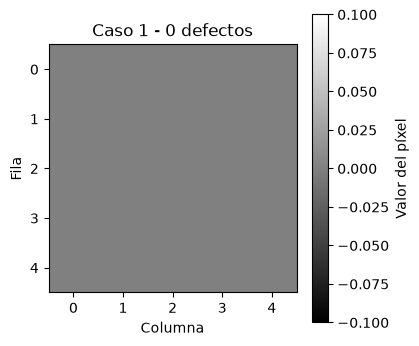

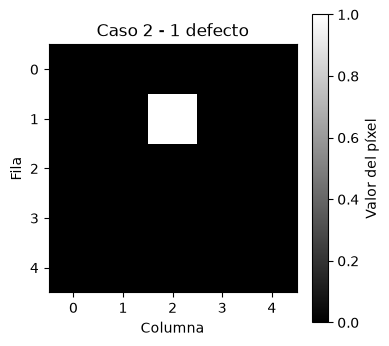

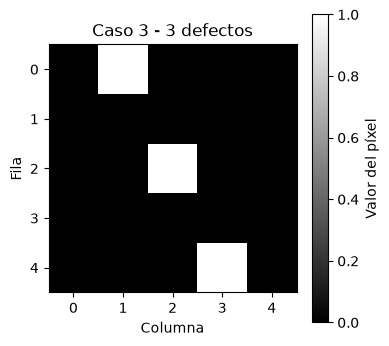

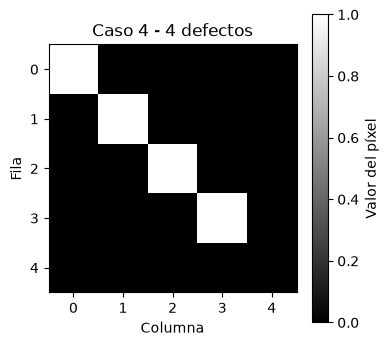

In [20]:
import matplotlib.pyplot as plt

for nombre, imagen in imagenes:
    
    plt.figure(figsize=(4, 4))
    plt.imshow(imagen, cmap="gray")
    plt.title(nombre)
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.colorbar(label="Valor del píxel")
    plt.show()